# Outer approximation of Julia set

**Adapted from**: Section 7.1.3 of [KHJ14]

[KHJ14] Milan Korda, Didier Henrion, and Colin N. Jones.
*Convex computation of the maximum controlled invariant set for polynomial control systems*.
SIAM Journal on Control and Optimization 52.5 (2014): 2944-2969.

The Julia map is defined as follows:

In [1]:
function julia_map(point, c)
    a, b = point
    return [a^2 - b^2 + real(c), 2a * b + imag(c)]
end

julia_map (generic function with 1 method)

The *escape radius" is the radius `r` such that `r^2 ≥ r + abs(c)`.
Ouside of the circle of that radius, all points diverge so we know the Julia set belongs to that circle.

In [2]:
escape_radius(c) = (1 + √(1 + 4 * abs(c))) / 2

escape_radius (generic function with 1 method)

To check whether a point is in the Julia set, we can iterate and once the point leaves the circle of escape radius,
we consider that it is not in the Julia set, if it stays in the set, we consider that it is in the Julia set.
This gives an outer approximation that converges to the Julia set when `m` increases.

In [3]:
using LinearAlgebra
function in_set(x, c, m=2000)
    r = escape_radius(c)
    for i in 1:m
        if norm(x) > r
            return false
        end
        x = julia_map(x, c)
    end
    return true
end

in_set (generic function with 2 methods)

To sort of minimize a level set of a polynomial we minimize integral of that polynomial.
We borrow the following from [here](https://doi.org/10.1080/00029890.2001.11919774).

In [4]:
using SpecialFunctions
using DynamicPolynomials
β(α) = (α + 1) / 2
function circle_integral(mono::AbstractMonomial)
    if any(isodd, exponents(mono))
        return 0.0
    else
        return 2 * prod(gamma ∘ β, exponents(mono)) / gamma(sum(β, exponents(mono)))
    end
end
function disk_integral(mono::AbstractMonomial, r)
    d = degree(mono) + nvariables(mono)
    return circle_integral(mono) * r^d / d
end
function disk_integral(p::AbstractPolynomialLike, r)
    return sum(MultivariatePolynomials.coefficient(t) * disk_integral(monomial(t), r) for t in terms(p))
end

disk_integral (generic function with 2 methods)

The following function implements [KHJ14, (8)].

In [5]:
using SumOfSquares
function outer_approximation(solver, d::Int, c; α = 1/2)
    @polyvar x[1:2]
    model = SOSModel(solver)
    r = escape_radius(c)
    S = @set sum(x.^2) <= r^2
    @variable(model, v, Poly(monomials(x, 0:2d)))
    @variable(model, w0, SOSPoly(monomials(x, 0:d)))
    @variable(model, w1, SOSPoly(monomials(x, 0:(d - 1))))
    @constraint(model, α * v(x => julia_map(x, c)) <= v, domain = S)
    w = w0 + w1 * (r^2 - sum(x.^2))
    @constraint(model, w >= v + 1, domain = S)
    @objective(model, Min, disk_integral(w, r))
    optimize!(model)
    if primal_status(model) == MOI.NO_SOLUTION
        return
    end
    return model
end

outer_approximation (generic function with 1 method)

The following function plots the Julia set with the outer approximation.

In [6]:
using ImplicitPlots
using Plots
function julia_plot(poly, c, n=200, m=1000; tol=1e-6, res = 1000)
    r = escape_radius(c)
    p = implicit_plot(poly; xlims=(-r, r) .* 1.1, ylims=(-r, r), resolution = res, label="")
    θ = range(0, stop=2π, length=100)
    points = Vector{Float64}[]
    as = range(-r, r, length=n)
    bs = range(-r, r, length=n)
    for a in as, b in bs
        point = [a, b]
        if in_set(point, c, m)
            push!(points, point)
        end
    end
    xs = [point[1] for point in points]
    ys = [point[2] for point in points]
    scatter!(p, xs, ys, label="", markerstrokewidth=0, markersize=1.5, m=:pixel)
    return p
end

julia_plot (generic function with 3 methods)

We need to pick an SDP solver, see [here](https://jump.dev/JuMP.jl/v1.12/installation/#Supported-solvers) for a list of the available choices.

In [7]:
import Clarabel
solver = optimizer_with_attributes(Clarabel.Optimizer, MOI.Silent() => true)

MathOptInterface.OptimizerWithAttributes(Clarabel.MOIwrapper.Optimizer, Pair{MathOptInterface.AbstractOptimizerAttribute, Any}[MathOptInterface.Silent() => true])

Let's start with the value of `c` corresponding to the left image of [KHJ14, Figure 3] and with degree 2.

In [8]:
c = -0.7 + 0.2im
model = outer_approximation(solver, 2, c)
solution_summary(model)

solution_summary(; result = 1, verbose = false)
├ solver_name          : Clarabel
├ Termination
│ ├ termination_status : OPTIMAL
│ ├ result_count       : 1
│ └ raw_status         : SOLVED
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : FEASIBLE_POINT
│ ├ objective_value      : 6.02400e+00
│ └ dual_objective_value : 6.02400e+00
└ Work counters
  ├ solve_time (sec)   : 2.79653e-01
  └ barrier_iterations : 13

We visualize below:

┌ Warning: Skipped marker arg pixel.
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1155


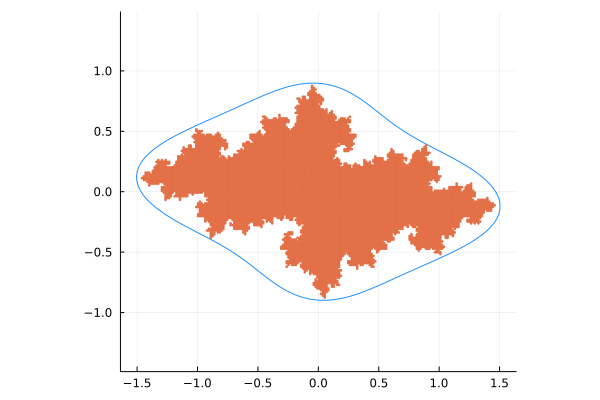

In [9]:
julia_plot(value(model[:v]), c)

Let's now look at degree 4.

In [10]:
model = outer_approximation(solver, 4, c)
solution_summary(model)

solution_summary(; result = 1, verbose = false)
├ solver_name          : Clarabel
├ Termination
│ ├ termination_status : OPTIMAL
│ ├ result_count       : 1
│ └ raw_status         : SOLVED
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : FEASIBLE_POINT
│ ├ objective_value      : 5.03038e+00
│ └ dual_objective_value : 5.03038e+00
└ Work counters
  ├ solve_time (sec)   : 2.01945e+01
  └ barrier_iterations : 24

We visualize below:

┌ Warning: Skipped marker arg pixel.
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1155


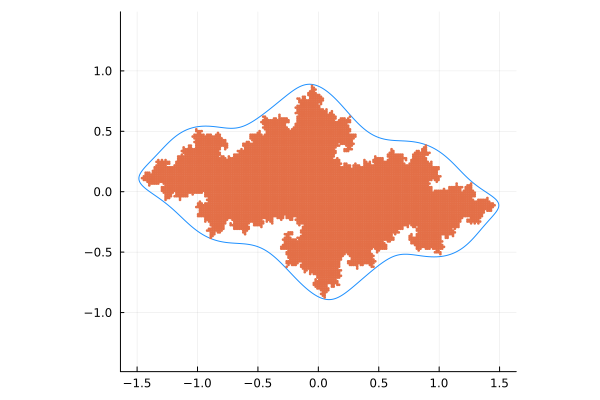

In [11]:
julia_plot(value(model[:v]), c)

Let's now use the value of `c` corresponding to the right image of [KHJ14, Figure 3] and with degree 2.

In [12]:
c = -0.9 + 0.2im
model = outer_approximation(solver, 2, c)
solution_summary(model)

solution_summary(; result = 1, verbose = false)
├ solver_name          : Clarabel
├ Termination
│ ├ termination_status : OPTIMAL
│ ├ result_count       : 1
│ └ raw_status         : SOLVED
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : FEASIBLE_POINT
│ ├ objective_value      : 6.57446e+00
│ └ dual_objective_value : 6.57446e+00
└ Work counters
  ├ solve_time (sec)   : 2.19507e-02
  └ barrier_iterations : 15

We visualize below:

┌ Warning: Skipped marker arg pixel.
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1155


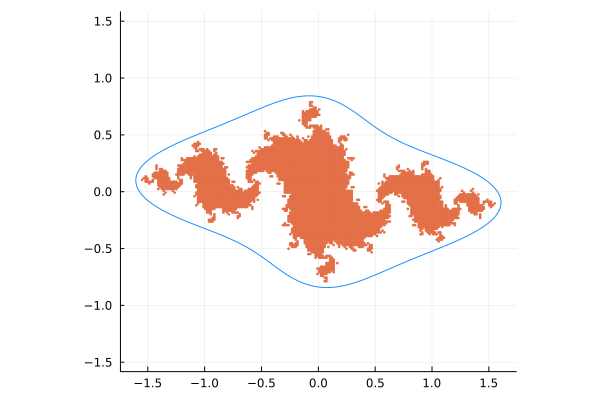

In [13]:
julia_plot(value(model[:v]), c)

Let's now look at degree 4.

In [14]:
model = outer_approximation(solver, 4, c)
solution_summary(model)

solution_summary(; result = 1, verbose = false)
├ solver_name          : Clarabel
├ Termination
│ ├ termination_status : OPTIMAL
│ ├ result_count       : 1
│ └ raw_status         : SOLVED
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : FEASIBLE_POINT
│ ├ objective_value      : 5.04104e+00
│ └ dual_objective_value : 5.04104e+00
└ Work counters
  ├ solve_time (sec)   : 2.61640e+01
  └ barrier_iterations : 24

We visualize below:

┌ Warning: Skipped marker arg pixel.
└ @ Plots ~/.julia/packages/Plots/GIume/src/args.jl:1155


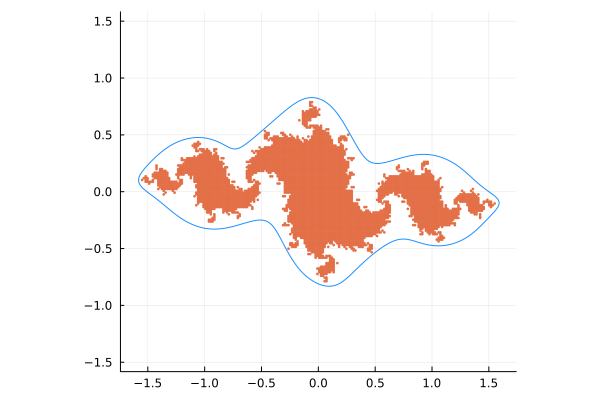

In [15]:
julia_plot(value(model[:v]), c)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*